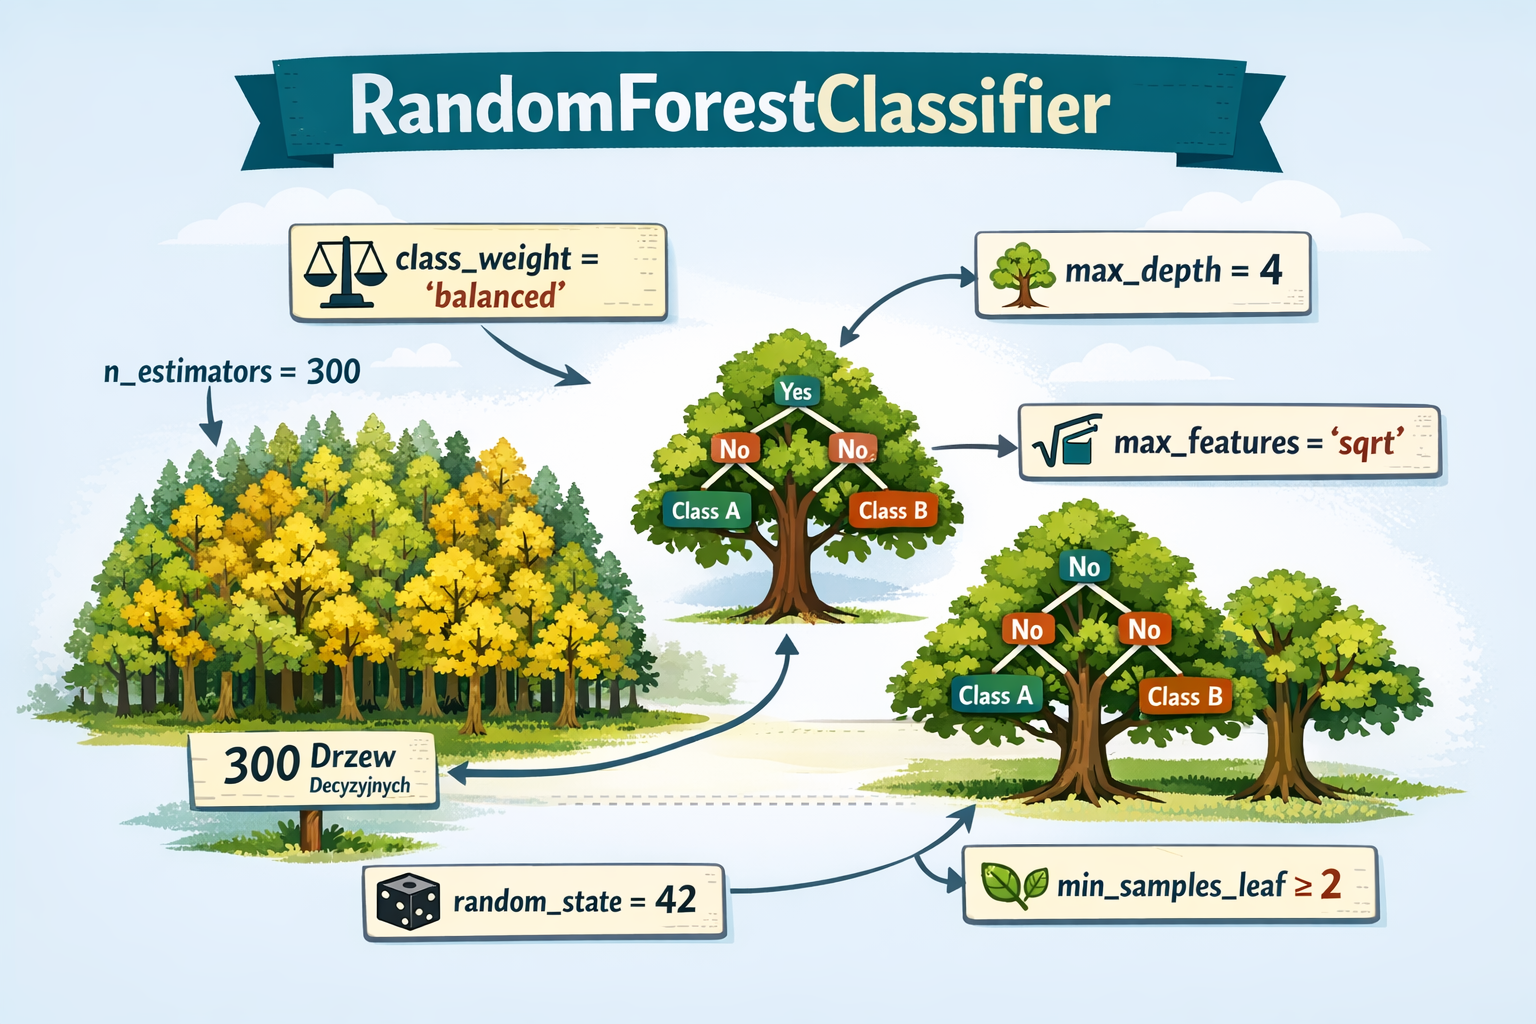

🌳 1. Lewa strona — „las” drzew

👉 n_estimators = 300

Widzisz duży „las” z wieloma drzewami

Każde drzewo = jeden Decision Tree

Tu masz ich 300

📌 Interpretacja:

Model nie opiera się na jednym drzewie, tylko na wielu (ensemble)

Każde drzewo daje swoją predykcję

Na końcu robione jest głosowanie (majority voting)

🌳 2. Pojedyncze drzewo (środek i prawa strona)

To są przykładowe drzewa decyzyjne.

Co widzisz:

Węzły z pytaniami: Yes / No

Na końcu:

Class A

Class B

📌 Interpretacja:

Każde drzewo podejmuje decyzję na podstawie cech

To jest klasyczny Decision Tree classifier

🌲 3. max_depth = 4 (góra po prawej)

👉 Oznacza maksymalną głębokość drzewa

Na rysunku:

Drzewa są „niskie” (mało poziomów)

📌 Interpretacja:

Maksymalnie 4 poziomy decyzji

Chroni przed overfittingiem

👉 Intuicja:

płytkie drzewo = prostsze reguły

głębokie drzewo = bardziej dopasowane (ryzyko overfitting)

🔢 4. max_features = "sqrt"

Na rysunku:

Strzałka do drzewa + symbol √

📌 Interpretacja:

Każde drzewo widzi tylko losowy podzbiór cech

Liczba cech = √(liczba wszystkich cech)

👉 Dlaczego?

zwiększa różnorodność drzew

zmniejsza korelację między nimi

🍃 5. min_samples_leaf = 2

Na rysunku:

Liść z oznaczeniem „≥ 2”

📌 Interpretacja:

Każdy końcowy liść musi mieć minimum 2 próbki

👉 Efekt:

brak „przeuczenia” na pojedynczych obserwacjach

bardziej stabilne predykcje

⚖️ 6. class_weight = "balanced"

Na rysunku:

symbol wagi ⚖️

📌 Interpretacja:

model automatycznie „wyrównuje” klasy

👉 Jeśli masz np.:

90% klasy 0

10% klasy 1

to model:

daje większą wagę klasie 1

👉 Efekt:

lepsze wykrywanie rzadkich przypadków (np. fraud)

🎲 7. random_state = 42

Na rysunku:

kostka 🎲

📌 Interpretacja:

kontroluje losowość:

losowanie próbek (bootstrap)

losowanie cech

👉 Efekt:

zawsze dostaniesz ten sam wynik przy ponownym uruchomieniu

🔁 8. Strzałki między drzewami

📌 Pokazują:

że każde drzewo jest budowane niezależnie

ale wszystkie razem tworzą finalny model

🧠 Najważniejszy insight

👉 Random Forest =
wiele prostych drzew + losowość + głosowanie

A te parametry sterują:

Parametr	Co kontroluje
n_estimators	ile drzew
max_depth	złożoność pojedynczego drzewa
max_features	losowość cech
min_samples_leaf	stabilność liści
class_weight	balans klas
random_state	powtarzalność

a na samym koncu jak jest brany wynik ? 

Świetne pytanie — to jest klucz do zrozumienia Random Forest 🔥

🧠 Co się dzieje NA SAMYM KOŃCU?

Masz:

300 drzew (n_estimators = 300)

każde drzewo daje swoją odpowiedź

👉 Krok 1: każde drzewo przewiduje klasę

Dla jednej obserwacji:

Drzewo 1 → Class A
Drzewo 2 → Class B
Drzewo 3 → Class A
...
Drzewo 300 → Class A
🗳️ Krok 2: głosowanie (majority voting)

Model liczy głosy:

Class A → 210 głosów
Class B → 90 głosów

👉 Wynik końcowy:

Class A
📊 A co z prawdopodobieństwem?

Random Forest nie tylko daje klasę, ale też:

👉 predict_proba()

Liczy proporcję głosów:

P(Class A) = 210 / 300 = 0.70
P(Class B) = 90 / 300 = 0.30
🎯 Krok 3: threshold (próg decyzyjny)

Domyślnie:

jeśli P(Class 1) > 0.5 → klasa 1

ALE 👇 (to ważne dla Ciebie)

👉 Możesz zmienić threshold, np.:

jeśli P(Class 1) > 0.3 → klasa 1
🔥 Bardzo ważny insight

👉 Random Forest = średnia z wielu opinii

Nie ufa jednemu drzewu, tylko:

final prediction = agregacja wszystkich drzew
📦 Jak to wygląda „matematycznie”

Dla klasyfikacji:

ŷ = argmax (średnia predykcji z drzew)

Dla prawdopodobieństwa:

P(y=1) = (liczba drzew przewidujących 1) / (liczba drzew)
⚖️ Gdzie wchodzi class_weight="balanced"?

👉 Każde drzewo:

„bardziej przejmuje się” rzadką klasą

Efekt:

więcej drzew zaczyna głosować na klasę 1

zmienia się końcowa proporcja

🧠 Intuicja (najprościej)

Wyobraź sobie:

300 analityków finansowych

każdy daje swoją decyzję

finalnie bierzesz głos większości

👉 to właśnie robi Random Forest

🚀 Powiązanie z Twoim pytaniem o threshold

To co wcześniej mówiłeś:

„threshold musi być dopasowany do rozkładu”

👉 Teraz widzisz dlaczego:

Bo:

model daje rozkład głosów

a Ty decydujesz, gdzie jest granica

Jeśli chcesz, mogę pokazać Ci:
👉 kiedy majority voting zawodzi i dlaczego czasem lepiej patrzeć na predict_proba() niż predict() (to jest bardzo ważne w ML w finansach)

czy to nie jest subiektywne manipulacja class_weight="balanced" ? po to by karal za pomylki klasy do ktorej na poczatku wiecej przypsiuje wynikow ? 

Bardzo dobre pytanie — i dobrze, że masz takie wątpliwości, bo to dotyka sedna ML 👇

❗ Krótka odpowiedź

👉 Nie, to nie jest manipulacja — to jest świadome ustawienie funkcji kosztu (lossu)
Ale:
👉 tak, to jest subiektywna decyzja biznesowa

🧠 Co robi class_weight="balanced" naprawdę?

Bez tego:

Model traktuje wszystkie błędy tak samo:

błąd na klasie 0 = błąd na klasie 1

Ale jeśli masz dane np.:

90% → klasa 0

10% → klasa 1

to model „naturalnie” uczy się:
👉 „lepiej zawsze mówić 0”

⚖️ Co zmienia balanced?

Model dostaje informację:

👉 „hej, pomyłka na rzadkiej klasie jest ważniejsza”

Czyli w uproszczeniu:

błąd dla klasy 1 = większa kara
błąd dla klasy 0 = mniejsza kara
🔥 Czy to manipulacja?
❌ Nie (z perspektywy ML)

Bo:

model nadal uczy się z danych

nic nie jest „ręcznie ustawiane”

zmieniasz tylko priorytety błędów

To jest standardowa praktyka:
👉 tak samo jak zmiana thresholdu

✅ Tak (z perspektywy decyzji biznesowej)

Bo wybierasz:

co jest ważniejsze:

false positive

false negative

📊 Przykład (bardzo ważny)
💳 Fraud detection

1% fraud

99% normalne transakcje

Bez balanced:
👉 model powie „brak fraudu” zawsze
👉 accuracy = 99% 😅 (ale model bezużyteczny)

Z balanced:
👉 model zaczyna wykrywać fraudy
👉 kosztem większej liczby false alarmów

🧠 Najważniejszy insight

👉 ML to nie jest „obiektywna prawda”

To jest:

optymalizacja względem tego, co uznasz za ważne
🔁 class_weight vs threshold

To co robisz:

Mechanizm	Kiedy działa
class_weight	podczas trenowania
threshold	po trenowaniu

👉 Oba wpływają na:

precision

recall

⚠️ Kiedy to jest faktycznie „złe użycie”?

👉 Jeśli:

sztucznie „pompusz” klasę bez powodu

nie masz uzasadnienia biznesowego

nie sprawdzasz metryk (precision/recall)

💡 Dla Twojego projektu (USD/PLN)

To jest mega ważne 👇

Zastanów się:

👉 co jest gorsze:

❌ przewidzieć wzrost, a będzie spadek

❌ przewidzieć spadek, a będzie wzrost

Bo wtedy:

możesz ustawić class_weight

albo threshold

🚀 Podsumowanie

👉 class_weight="balanced" to NIE manipulacja danych
👉 to świadome powiedzenie modelowi:

„nie wszystkie błędy są równie ważne”

Jeśli chcesz, mogę Ci pokazać na liczbach:
👉 jak dokładnie zmieniają się precision i recall po włączeniu balanced (to często otwiera oczy 💡)

pokaz, moze na przykladzie fraud  ? 


Super — pokażę Ci to na bardzo konkretnym przykładzie fraud 💳, żebyś zobaczył liczby, a nie teorię.

🎯 Założenia problemu

Masz 10 000 transakcji:

9 900 → brak fraudu (klasa 0)

100 → fraud (klasa 1) ❗ (tylko 1%)

🔴 Model BEZ class_weight

Model „idzie na łatwiznę” i przewiduje głównie 0.

📊 Wynik (confusion matrix):
	Pred 0	Pred 1
Real 0	9700	200
Real 1	80	20
📈 Metryki:

Precision (fraud) = 20 / (20 + 200) = 0.09 😬

Recall (fraud) = 20 / (20 + 80) = 0.20

Accuracy = (9700 + 20) / 10000 = 97.2% 🤡

👉 Wniosek:

accuracy wygląda świetnie

model prawie nie wykrywa fraudów

🟢 Model Z class_weight="balanced"

Model dostaje sygnał:
👉 „fraud jest ważny — nie ignoruj go”

📊 Wynik:
	Pred 0	Pred 1
Real 0	9000	900
Real 1	30	70
📈 Metryki:

Precision (fraud) = 70 / (70 + 900) = 0.07 😬 (spadło!)

Recall (fraud) = 70 / (70 + 30) = 0.70 🔥 (duży wzrost!)

Accuracy = (9000 + 70) / 10000 = 90.7%

🤯 Co się właśnie stało?
Metryka	Bez balanced	Z balanced
Recall (fraud)	❌ 0.20	✅ 0.70
Precision	0.09	0.07
Accuracy	97%	90%
🧠 Interpretacja

👉 Model zaczął mówić:

„wolę złapać więcej fraudów, nawet jeśli się pomylę”

Czyli:

więcej True Positives ✅

ale też więcej False Positives ❌

⚖️ Czy to ma sens biznesowo?
💳 W fraud detection:

👉 TAK

Bo:

lepiej zablokować dobrą transakcję (do sprawdzenia)

niż przepuścić fraud 💸

🔥 Najważniejszy insight

👉 class_weight NIE poprawia modelu „magicznie”

On robi trade-off:

więcej recall  ⇄  mniej precision
🚀 Jeszcze głębszy insight (ważny dla Ciebie)

👉 To samo możesz osiągnąć przez threshold

Np.:

threshold = 0.2 zamiast 0.5

Efekt:

więcej klasy 1

większy recall

🧠 Różnica:
Podejście	Kiedy działa
class_weight	zmienia uczenie modelu
threshold	zmienia decyzję końcową
🎯 Najlepsza praktyka

👉 w realnym projekcie robisz:

trenujesz model (czasem z balanced)

bierzesz predict_proba()

dobierasz threshold pod biznes

💡 TL;DR

👉 balanced mówi:

„nie ignoruj rzadkiej klasy”

👉 i płacisz za to:

większą liczbą false alarmów

Jeśli chcesz, mogę zrobić kolejny krok:
👉 pokażę Ci jak dobrać idealny threshold na wykresie (precision-recall curve) — to jest dokładnie to, co robią banki i fintechy.

reszta tutaj : https://chatgpt.com/c/69bd4e2b-c348-8333-a392-e46a2b58b915
